# Task 3: Sentiment Classification
## SST2 and SST Sentiment Classification

This notebook covers two sentiment datasets:
- **SST2**: binary positive/negative classification
- **SST**: fine-grained sentiment labels from the Stanford Sentiment Treebank

The notebook is organized into short sections:
1. Environment setup and imports
2. Loading SST2 with pandas parquet files
3. Loading SST with the Hugging Face dataset script
4. Quick exploration and label inspection
5. Tokenization and preprocessing
6. Baseline transformer training
7. Evaluation, inference, and comparison

Goal: build a clear sentiment classification workflow that is easy to read and reproduce.

## 1. Environment Setup

Install or confirm the dependencies, then import the libraries used for loading data, preprocessing, training, and evaluation.

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings

# Transformers and datasets
from datasets import Dataset, DatasetDict, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline
)
import torch

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

/home/mohamed-abdelhady/Coding/Cutting-Out-the-Middleman/.venv-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!
PyTorch version: 2.5.1+cu121
GPU available: True


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings

# Transformers and datasets
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline
)
import torch

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

Libraries imported successfully!
PyTorch version: 2.5.1+cu121
GPU available: True


## 2. Load and Explore Dataset 1: SST2

SST2 is the binary version of the Stanford Sentiment Treebank. Here we follow the requested workflow and load the dataset directly from the Hugging Face parquet files using `pandas`.

**Why this section matters:**
- It matches the exact dataset format requested for the task
- It gives a simple DataFrame view before converting to Hugging Face datasets
- It keeps the rest of the notebook compatible with the transformer training pipeline

In [3]:
# Load SST2 dataset from the Hugging Face parquet files using pandas
print("Loading SST2 parquet splits...")
sst2_splits = {
    'train': 'data/train-00000-of-00001.parquet',
    'validation': 'data/validation-00000-of-00001.parquet',
    'test': 'data/test-00000-of-00001.parquet'
}

sst2_train_df = pd.read_parquet("hf://datasets/stanfordnlp/sst2/" + sst2_splits["train"])
sst2_validation_df = pd.read_parquet("hf://datasets/stanfordnlp/sst2/" + sst2_splits["validation"])
sst2_test_df = pd.read_parquet("hf://datasets/stanfordnlp/sst2/" + sst2_splits["test"])

print("\nSST2 DataFrame previews:")
print("Train:")
print(sst2_train_df.head())
print("\nValidation:")
print(sst2_validation_df.head())
print("\nTest:")
print(sst2_test_df.head())

sst2_dataset = DatasetDict({
    "train": Dataset.from_pandas(sst2_train_df, preserve_index=False),
    "validation": Dataset.from_pandas(sst2_validation_df, preserve_index=False),
    "test": Dataset.from_pandas(sst2_test_df, preserve_index=False)
})

print("\nDataset splits:")
print(sst2_dataset)

# Get dataset info
print("\nDataset features:")
print(sst2_dataset['train'].features)

print(f"\nTraining set size: {len(sst2_dataset['train'])}")
print(f"Validation set size: {len(sst2_dataset['validation'])}")
print(f"Test set size: {len(sst2_dataset['test'])}")

Loading SST2 parquet splits...

SST2 DataFrame previews:
Train:
   idx                                           sentence  label
0    0       hide new secretions from the parental units       0
1    1               contains no wit , only labored gags       0
2    2  that loves its characters and communicates som...      1
3    3  remains utterly satisfied to remain the same t...      0
4    4  on the worst revenge-of-the-nerds clichés the ...      0

Validation:
   idx                                           sentence  label
0    0    it 's a charming and often affecting journey .       1
1    1                 unflinchingly bleak and desperate       0
2    2  allows us to hope that nolan is poised to emba...      1
3    3  the acting , costumes , music , cinematography...      1
4    4                  it 's slow -- very , very slow .       0

Test:
   idx                                           sentence  label
0    0             uneasy mishmash of styles and genres .     -1
1    1

In [4]:
# Explore SST2 data samples
print("Sample reviews from SST2:")
print("="*80)

for i in range(5):
    sample = sst2_dataset['train'][i]
    sentiment = "Positive" if sample['label'] == 1 else "Negative"
    print(f"\nSample {i+1}:")
    print(f"Text: {sample['sentence']}")
    print(f"Label: {sentiment} ({sample['label']})")
    print("-"*80)

Sample reviews from SST2:

Sample 1:
Text: hide new secretions from the parental units 
Label: Negative (0)
--------------------------------------------------------------------------------

Sample 2:
Text: contains no wit , only labored gags 
Label: Negative (0)
--------------------------------------------------------------------------------

Sample 3:
Text: that loves its characters and communicates something rather beautiful about human nature 
Label: Positive (1)
--------------------------------------------------------------------------------

Sample 4:
Text: remains utterly satisfied to remain the same throughout 
Label: Negative (0)
--------------------------------------------------------------------------------

Sample 5:
Text: on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
Label: Negative (0)
--------------------------------------------------------------------------------


Label distribution in SST2 Training Set:
0    29780
1    37569
Name: count, dtype: int64

Positive: 37569 (55.78%)
Negative: 29780 (44.22%)


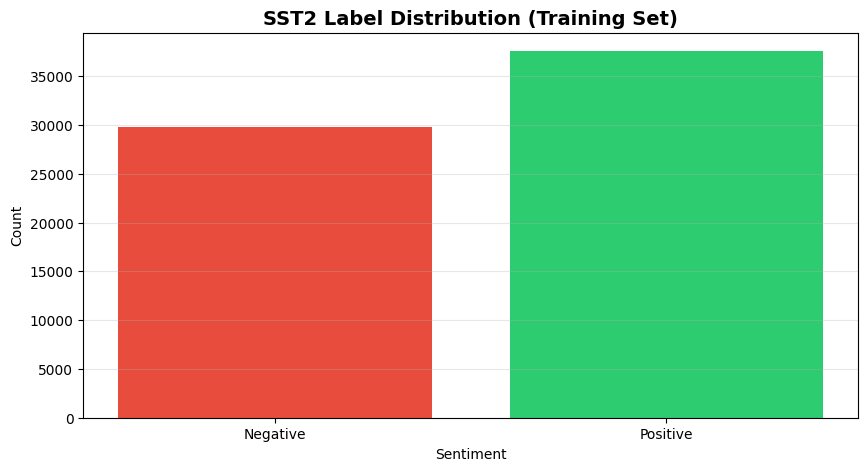

In [5]:
# Analyze label distribution in SST2
train_labels_sst2 = [sample['label'] for sample in sst2_dataset['train']]
label_counts_sst2 = pd.Series(train_labels_sst2).value_counts().sort_index()

print("Label distribution in SST2 Training Set:")
print(label_counts_sst2)
print(f"\nPositive: {label_counts_sst2[1]} ({label_counts_sst2[1]/len(train_labels_sst2)*100:.2f}%)")
print(f"Negative: {label_counts_sst2[0]} ({label_counts_sst2[0]/len(train_labels_sst2)*100:.2f}%)")

# Visualize
plt.figure(figsize=(10, 5))
plt.bar(['Negative', 'Positive'], [label_counts_sst2[0], label_counts_sst2[1]], color=['#e74c3c', '#2ecc71'])
plt.title('SST2 Label Distribution (Training Set)', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Sentiment')
plt.grid(axis='y', alpha=0.3)
plt.show()

Text length statistics (SST2):
Min length: 1 words
Max length: 52 words
Average length: 9.41 words
Median length: 7.00 words


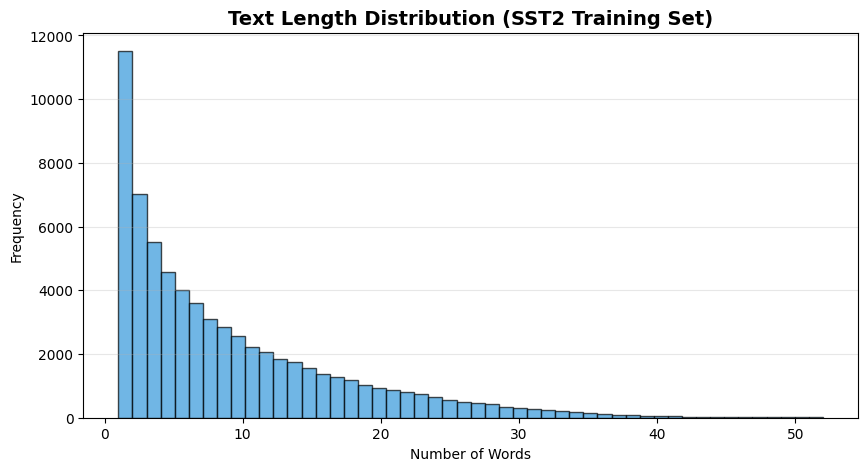

In [6]:
# Text length analysis
text_lengths_sst2 = [len(sample['sentence'].split()) for sample in sst2_dataset['train']]

print("Text length statistics (SST2):")
print(f"Min length: {min(text_lengths_sst2)} words")
print(f"Max length: {max(text_lengths_sst2)} words")
print(f"Average length: {np.mean(text_lengths_sst2):.2f} words")
print(f"Median length: {np.median(text_lengths_sst2):.2f} words")

plt.figure(figsize=(10, 5))
plt.hist(text_lengths_sst2, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
plt.title('Text Length Distribution (SST2 Training Set)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 3. Load and Explore Dataset 2: SST (Full)

The Hugging Face `stanfordnlp/sst` repo still depends on a loading script, and the current `datasets` release in this environment no longer supports that script. To keep the notebook runnable, this section loads the original Stanford SST source archive and reproduces the same default split.

**Why this section matters:**
- It gives access to the original SST sentiment treebank structure
- It includes sentence text, labels, tokens, and parse-tree information
- It stays compatible with the rest of the notebook even when HF script loading is disabled

In [7]:
# Load SST dataset from the original Stanford source archive
from pathlib import Path
import csv
import urllib.request
import zipfile

print("Loading SST dataset from Stanford source files...")

sst_cache_dir = Path("data/sst")
sst_cache_dir.mkdir(parents=True, exist_ok=True)
sst_zip_path = sst_cache_dir / "stanfordSentimentTreebank.zip"
sst_extract_dir = sst_cache_dir / "stanfordSentimentTreebank"
sst_source_url = "https://nlp.stanford.edu/~socherr/stanfordSentimentTreebank.zip"

if not sst_zip_path.exists():
    print("Downloading Stanford Sentiment Treebank archive...")
    urllib.request.urlretrieve(sst_source_url, sst_zip_path)

if not sst_extract_dir.exists():
    print("Extracting archive...")
    with zipfile.ZipFile(sst_zip_path, "r") as zip_file:
        zip_file.extractall(sst_cache_dir)

phrases_path = sst_extract_dir / "dictionary.txt"
labels_path = sst_extract_dir / "sentiment_labels.txt"
tokens_path = sst_extract_dir / "SOStr.txt"
trees_path = sst_extract_dir / "STree.txt"
splits_path = sst_extract_dir / "datasetSplit.txt"
sentences_path = sst_extract_dir / "datasetSentences.txt"

labels = {}
with open(labels_path, encoding="utf-8") as label_file:
    label_reader = csv.DictReader(label_file, delimiter="|", quoting=csv.QUOTE_NONE)
    for row in label_reader:
        labels[row["phrase ids"]] = float(row["sentiment values"])

phrases = {}
with open(phrases_path, encoding="utf-8") as phrase_file:
    phrase_reader = csv.reader(phrase_file, delimiter="|", quoting=csv.QUOTE_NONE)
    for row in phrase_reader:
        phrases[row[0]] = labels[row[1]]

trees = {}
with open(tokens_path, encoding="utf-8") as token_file, open(trees_path, encoding="utf-8") as tree_file:
    token_reader = csv.reader(token_file, delimiter="\t", quoting=csv.QUOTE_NONE)
    tree_reader = csv.reader(tree_file, delimiter="\t", quoting=csv.QUOTE_NONE)
    for i, row in enumerate(token_reader, start=1):
        trees[i] = {"tokens": row[0]}
    for i, row in enumerate(tree_reader, start=1):
        trees[i]["tree"] = row[0]

sentence_splits = {}
with open(splits_path, encoding="utf-8") as split_file:
    split_reader = csv.DictReader(split_file, delimiter=",", quoting=csv.QUOTE_NONE)
    for row in split_reader:
        sentence_splits[row["sentence_index"]] = row["splitset_label"]

sst_records = []
with open(sentences_path, encoding="utf-8") as sentence_file:
    sentence_reader = csv.DictReader(sentence_file, delimiter="\t", quoting=csv.QUOTE_NONE)
    for row in sentence_reader:
        sentence_text = (
            row["sentence"]
            .encode("utf-8")
            .replace(b"\xc3\x83\xc2", b"\xc3")
            .replace(b"\xc3\x82\xc2", b"\xc2")
            .decode("utf-8")
            .replace("-LRB-", "(")
            .replace("-RRB-", ")")
        )
        split_code = sentence_splits[row["sentence_index"]]
        if split_code == "1":
            split_name = "train"
        elif split_code == "3":
            split_name = "validation"
        elif split_code == "2":
            split_name = "test"
        else:
            continue

        sst_records.append(
            {
                "sentence": sentence_text,
                "label": phrases[sentence_text],
                "tokens": trees[int(row["sentence_index"])] ["tokens"],
                "tree": trees[int(row["sentence_index"])] ["tree"],
                "split": split_name,
            }
        )

sst_df = pd.DataFrame(sst_records)
sst_train_df = sst_df[sst_df["split"] == "train"].drop(columns=["split"]).reset_index(drop=True)
sst_validation_df = sst_df[sst_df["split"] == "validation"].drop(columns=["split"]).reset_index(drop=True)
sst_test_df = sst_df[sst_df["split"] == "test"].drop(columns=["split"]).reset_index(drop=True)

sst_dataset = DatasetDict(
    {
        "train": Dataset.from_pandas(sst_train_df, preserve_index=False),
        "validation": Dataset.from_pandas(sst_validation_df, preserve_index=False),
        "test": Dataset.from_pandas(sst_test_df, preserve_index=False),
    }
)

print("\nDataset splits:")
print(sst_dataset)

print("\nDataset features:")
print(sst_dataset['train'].features)

print(f"\nTraining set size: {len(sst_dataset['train'])}")
print(f"Validation set size: {len(sst_dataset['validation'])}")
print(f"Test set size: {len(sst_dataset['test'])}")

Loading SST dataset from Stanford source files...

Dataset splits:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'tokens', 'tree'],
        num_rows: 8544
    })
    validation: Dataset({
        features: ['sentence', 'label', 'tokens', 'tree'],
        num_rows: 1101
    })
    test: Dataset({
        features: ['sentence', 'label', 'tokens', 'tree'],
        num_rows: 2210
    })
})

Dataset features:
{'sentence': Value('large_string'), 'label': Value('float64'), 'tokens': Value('large_string'), 'tree': Value('large_string')}

Training set size: 8544
Validation set size: 1101
Test set size: 2210


In [8]:
# Explore SST data samples
print("Sample reviews from SST:")
print("="*80)

for i in range(3):
    sample = sst_dataset['train'][i]
    sentiment_map = {0.0: "Very Negative", 0.25: "Negative", 0.5: "Neutral", 0.75: "Positive", 1.0: "Very Positive"}
    sentiment = sentiment_map.get(sample['label'], "Unknown")
    
    print(f"\nSample {i+1}:")
    print(f"Text: {sample['sentence']}")
    print(f"Label: {sentiment} ({sample['label']})")
    print(f"Tokens: {sample['tokens'][:50]}..." if len(sample['tokens']) > 50 else f"Tokens: {sample['tokens']}")
    print("-"*80)

Sample reviews from SST:

Sample 1:
Text: The Rock is destined to be the 21st Century 's new `` Conan '' and that he 's going to make a splash even greater than Arnold Schwarzenegger , Jean-Claud Van Damme or Steven Segal .
Label: Unknown (0.69444)
Tokens: The|Rock|is|destined|to|be|the|21st|Century|'s|new...
--------------------------------------------------------------------------------

Sample 2:
Text: The gorgeously elaborate continuation of `` The Lord of the Rings '' trilogy is so huge that a column of words can not adequately describe co-writer\/director Peter Jackson 's expanded vision of J.R.R. Tolkien 's Middle-earth .
Label: Unknown (0.83333)
Tokens: The|gorgeously|elaborate|continuation|of|``|The|Lo...
--------------------------------------------------------------------------------

Sample 3:
Text: Singer\/composer Bryan Adams contributes a slew of songs -- a few potential hits , a few more simply intrusive to the story -- but the whole package certainly captures the intend

Label distribution in SST Training Set:
0.000000    16
0.013889    19
0.027778    18
0.041667    22
0.055556    74
            ..
0.944440    45
0.958330    17
0.972220    13
0.986110    11
1.000000    21
Name: count, Length: 74, dtype: int64


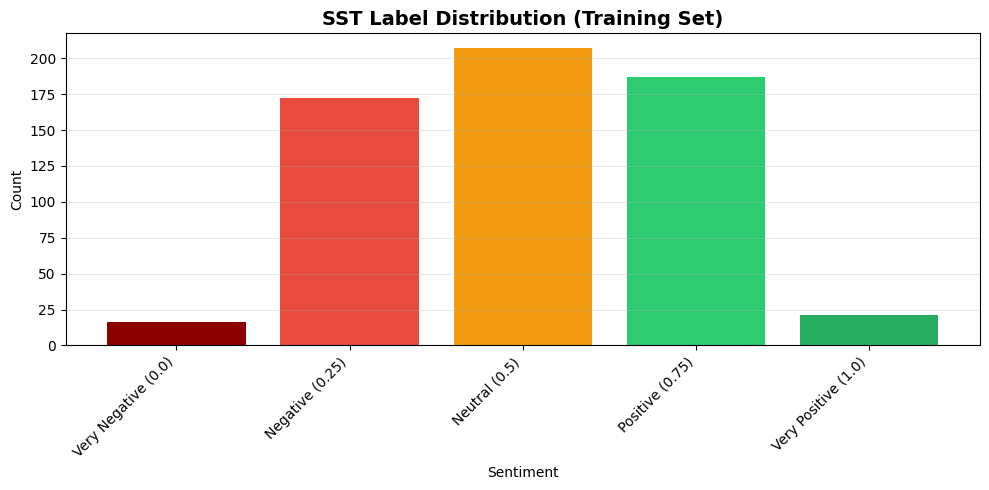

In [9]:
# Analyze label distribution in SST
train_labels_sst = [sample['label'] for sample in sst_dataset['train']]
label_counts_sst = pd.Series(train_labels_sst).value_counts().sort_index()

print("Label distribution in SST Training Set:")
print(label_counts_sst)

# Visualize
sentiment_labels = ["Very Negative (0.0)", "Negative (0.25)", "Neutral (0.5)", "Positive (0.75)", "Very Positive (1.0)"]
plt.figure(figsize=(10, 5))
plt.bar(sentiment_labels, [label_counts_sst.get(label, 0) for label in [0.0, 0.25, 0.5, 0.75, 1.0]], 
        color=['#8B0000', '#e74c3c', '#f39c12', '#2ecc71', '#27ae60'])
plt.title('SST Label Distribution (Training Set)', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Sentiment')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Tokenize and prepare data for transformer models.

**Preprocessing Steps:**
1. Load pre-trained tokenizer
2. Tokenize sentences
3. Apply padding and truncation
4. Create tensor datasets

In [10]:
# Select model and tokenizer
model_name = "distilbert-base-uncased"  # Lightweight baseline
# Alternative models:
# model_name = "bert-base-uncased"
# model_name = "roberta-base"

print(f"Loading tokenizer for {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
print("Tokenizer loaded successfully!")


Loading tokenizer for distilbert-base-uncased...


Tokenizer loaded successfully!


In [11]:
# Preprocess SST2 dataset
def preprocess_function_sst2(examples):
    return tokenizer(
        examples['sentence'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

print("Preprocessing SST2 dataset...")
sst2_encoded = sst2_dataset.map(
    preprocess_function_sst2,
    batched=True,
    batch_size=1000,
    num_proc=4,
    desc="Tokenizing SST2"
)
print("SST2 dataset preprocessed!")

# Set format to PyTorch tensors
sst2_encoded.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
print("SST2 dataset converted to PyTorch format!")


Preprocessing SST2 dataset...


Tokenizing SST2 (num_proc=4): 100%|██████████| 1821/1821 [00:00<00:00, 3285.06 examples/s]

SST2 dataset preprocessed!
SST2 dataset converted to PyTorch format!


In [12]:
# Preprocess SST dataset
def preprocess_function_sst(examples):
    return tokenizer(
        examples['sentence'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

print("Preprocessing SST dataset...")
sst_encoded = sst_dataset.map(
    preprocess_function_sst,
    batched=True,
    batch_size=1000,
    num_proc=4,
    desc="Tokenizing SST"
)
print("SST dataset preprocessed!")

# Set format to PyTorch tensors
sst_encoded.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
print("SST dataset converted to PyTorch format!")


Preprocessing SST dataset...


Tokenizing SST (num_proc=4): 100%|██████████| 2210/2210 [00:00<00:00, 3521.09 examples/s]

SST dataset preprocessed!
SST dataset converted to PyTorch format!


In [13]:
# Verify preprocessing
print("Sample preprocessed SST2 data:")
sample_sst2 = sst2_encoded['train'][0]
print(f"Input IDs shape: {sample_sst2['input_ids'].shape}")
print(f"Attention mask shape: {sample_sst2['attention_mask'].shape}")
print(f"Label: {sample_sst2['label']}")
print(f"\nDecoded text: {tokenizer.decode(sample_sst2['input_ids'])}")

Sample preprocessed SST2 data:
Input IDs shape: torch.Size([128])
Attention mask shape: torch.Size([128])
Label: 0

Decoded text: [CLS] hide new secretions from the parental units [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


## 5. Model Training on SST2

Train a DistilBERT model for binary sentiment classification on SST2.

**Training Strategy:**
- Fine-tune pre-trained model
- Use binary classification loss
- Monitor accuracy on validation set

In [14]:
# Create model for SST2
print(f"Loading model {model_name} for SST2 (binary classification)...")
model_sst2 = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=2  # Binary classification: Positive/Negative
)
print("Model loaded successfully!")
print(f"Model size: {model_sst2.num_parameters():,} parameters")

Loading model distilbert-base-uncased for SST2 (binary classification)...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4719.28it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!
Model size: 66,955,010 parameters


In [15]:
# Define training arguments
training_args_sst2 = TrainingArguments(
    output_dir='./results/sst2',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    report_to='none',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy'
)

print("Training arguments configured!")


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments configured!


In [ ]:
# Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {
        'accuracy': accuracy,
        'f1': f1
    }

# Create Trainer
trainer_sst2 = Trainer(
    model=model_sst2,
    args=training_args_sst2,
    train_dataset=sst2_encoded['train'],
    eval_dataset=sst2_encoded['validation'],
    compute_metrics=compute_metrics
)

print("Trainer initialized!")
print("\nStarting training...")

# Resume from latest checkpoint if it exists.
from pathlib import Path

sst2_output_dir = Path(training_args_sst2.output_dir)
resume_checkpoint_sst2 = None
if sst2_output_dir.exists():
    sst2_checkpoints = sorted(
        sst2_output_dir.glob('checkpoint-*'),
        key=lambda p: int(p.name.split('-')[-1]) if p.name.split('-')[-1].isdigit() else -1
    )
    if sst2_checkpoints:
        resume_checkpoint_sst2 = sst2_checkpoints[-1]

if resume_checkpoint_sst2 is not None:
    print(f"Resuming SST2 training from: {resume_checkpoint_sst2}")
    trainer_sst2.train(resume_from_checkpoint=str(resume_checkpoint_sst2))
else:
    print("No SST2 checkpoint found. Starting fresh training.")
    print('Starting SST2 training...', flush=True)
import sys; sys.stdout.flush()
trainer_sst2.train()
print('SST2 training completed!', flush=True)


Trainer initialized!

Starting training...
No SST2 checkpoint found. Starting fresh training.
🚀 Starting SST2 training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.160520,0.269128,0.889908,0.889820


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.49it/s]


## 6. Model Training on SST (Full)

Train a model on the full SST dataset with fine-grained sentiment labels.

**Note:** SST uses continuous labels (0.0-1.0), so we'll need to convert to discrete classes.

In [ ]:
# Convert continuous labels to discrete classes for SST
def convert_sst_labels(label):
    if label < 0.25:
        return 0  # Very Negative
    elif label < 0.5:
        return 1  # Negative
    elif label < 0.75:
        return 2  # Neutral
    else:
        return 3 if label < 0.9 else 4  # Positive / Very Positive

# Apply conversion
def add_discrete_labels(dataset):
    dataset = dataset.map(lambda x: {'discrete_label': convert_sst_labels(x['label'])}, batched=False)
    return dataset

print("Converting SST labels to discrete classes...")
sst_encoded = add_discrete_labels(sst_encoded)
sst_encoded.set_format(type='torch', columns=['input_ids', 'attention_mask', 'discrete_label'])
print("Labels converted!")

# Verify label distribution
labels_dist = [sample['discrete_label'].item() for sample in sst_encoded['train']]
print(f"\nLabel distribution: {pd.Series(labels_dist).value_counts().sort_index().to_dict()}")

In [ ]:
# Create model for SST (5-class classification)
print(f"Loading model {model_name} for SST (5-class classification)...")
model_sst = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5  # 5 sentiment classes
)
print("Model loaded successfully!")
print(f"Model size: {model_sst.num_parameters():,} parameters")

In [ ]:
# Define training arguments for SST
training_args_sst = TrainingArguments(
    output_dir='./results/sst',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    report_to='none',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy'
)

print("Training arguments configured for SST!")


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments configured for SST!


In [ ]:
# Create Trainer for SST
trainer_sst = Trainer(
    model=model_sst,
    args=training_args_sst,
    train_dataset=sst_encoded['train'],
    eval_dataset=sst_encoded['validation'],
    compute_metrics=compute_metrics
)

print("Trainer initialized for SST!")
print("\nStarting training...")

# Resume from latest checkpoint if it exists.
from pathlib import Path

sst_output_dir = Path(training_args_sst.output_dir)
resume_checkpoint_sst = None
if sst_output_dir.exists():
    sst_checkpoints = sorted(
        sst_output_dir.glob('checkpoint-*'),
        key=lambda p: int(p.name.split('-')[-1]) if p.name.split('-')[-1].isdigit() else -1
    )
    if sst_checkpoints:
        resume_checkpoint_sst = sst_checkpoints[-1]

if resume_checkpoint_sst is not None:
    print(f"Resuming SST training from: {resume_checkpoint_sst}")
    trainer_sst.train(resume_from_checkpoint=str(resume_checkpoint_sst))
else:
    print("No SST checkpoint found. Starting fresh training.")
    print('🚀 Starting SST training...', flush=True)
import sys; sys.stdout.flush()
trainer_sst.train()
print('✓ SST training completed!', flush=True)


## 7. Model Evaluation on Test Sets

Evaluate trained models on test datasets using multiple metrics.

**Metrics:**
- Accuracy
- F1-Score
- Confusion Matrix
- Classification Report

In [ ]:
# Evaluate SST2 on test set
print("Evaluating SST2 model on test set...")
eval_results_sst2 = trainer_sst2.evaluate(sst2_encoded['test'])
print(f"\nSST2 Test Results:")
for key, value in eval_results_sst2.items():
    print(f"{key}: {value:.4f}")

In [ ]:
# Get predictions on SST2 test set
print("Generating SST2 test predictions...")
predictions_sst2 = trainer_sst2.predict(sst2_encoded['test'])
pred_labels_sst2 = np.argmax(predictions_sst2.predictions, axis=1)
true_labels_sst2 = sst2_encoded['test']['label']

print("\nSST2 Detailed Metrics:")
print(f"Accuracy: {accuracy_score(true_labels_sst2, pred_labels_sst2):.4f}")
print(f"F1-Score: {f1_score(true_labels_sst2, pred_labels_sst2, average='weighted'):.4f}")
print(f"\nClassification Report:\n{classification_report(true_labels_sst2, pred_labels_sst2, target_names=['Negative', 'Positive'])}")

In [ ]:
# Confusion matrix for SST2
cm_sst2 = confusion_matrix(true_labels_sst2, pred_labels_sst2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_sst2, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('SST2 Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate SST on test set
print("Evaluating SST model on test set...")
eval_results_sst = trainer_sst.evaluate(sst_encoded['test'])
print(f"\nSST Test Results:")
for key, value in eval_results_sst.items():
    print(f"{key}: {value:.4f}")

In [ ]:
# Get predictions on SST test set
print("Generating SST test predictions...")
predictions_sst = trainer_sst.predict(sst_encoded['test'])
pred_labels_sst = np.argmax(predictions_sst.predictions, axis=1)
true_labels_sst = sst_encoded['test']['discrete_label']

print("\nSST Detailed Metrics:")
print(f"Accuracy: {accuracy_score(true_labels_sst, pred_labels_sst):.4f}")
print(f"F1-Score: {f1_score(true_labels_sst, pred_labels_sst, average='weighted'):.4f}")
print(f"\nClassification Report:\n{classification_report(true_labels_sst, pred_labels_sst, target_names=['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive'])}")

In [ ]:
# Confusion matrix for SST
cm_sst = confusion_matrix(true_labels_sst, pred_labels_sst)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_sst, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['Very Neg', 'Neg', 'Neutral', 'Pos', 'Very Pos'],
            yticklabels=['Very Neg', 'Neg', 'Neutral', 'Pos', 'Very Pos'],
            cbar_kws={'label': 'Count'})
plt.title('SST Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 8. Inference and Predictions

Use the trained models to make predictions on new, unseen text samples.

In [ ]:
# Create classification pipelines
print("Creating inference pipelines...")
classifier_sst2 = pipeline(
    'text-classification',
    model=model_sst2,
    tokenizer=tokenizer
)

classifier_sst = pipeline(
    'text-classification',
    model=model_sst,
    tokenizer=tokenizer
)

print("Pipelines created!")

In [ ]:
# Test samples
test_samples = [
    "This movie was absolutely amazing! I loved every minute of it.",
    "Terrible film. I fell asleep halfway through.",
    "It was okay, nothing special but watchable.",
    "Worst movie I've ever seen. Complete waste of time.",
    "Fantastic performance by the lead actor!"
]

print("SST2 Predictions (Binary Classification):")
print("="*80)
for sample in test_samples:
    result = classifier_sst2(sample)[0]
    label = "Positive" if result['label'] == 'LABEL_1' else "Negative"
    confidence = result['score']
    print(f"\nText: {sample}")
    print(f"Prediction: {label} (Confidence: {confidence:.4f})")

In [ ]:
print("\nSST Predictions (5-Class Classification):")
print("="*80)
sentiment_map = {
    'LABEL_0': 'Very Negative',
    'LABEL_1': 'Negative',
    'LABEL_2': 'Neutral',
    'LABEL_3': 'Positive',
    'LABEL_4': 'Very Positive'
}

for sample in test_samples:
    result = classifier_sst(sample)[0]
    label = sentiment_map.get(result['label'], 'Unknown')
    confidence = result['score']
    print(f"\nText: {sample}")
    print(f"Prediction: {label} (Confidence: {confidence:.4f})")

## 9. Performance Comparison

Compare models and datasets performance side by side.

In [ ]:
# Create comparison dataframe
comparison_data = {
    'Metric': ['Accuracy', 'F1-Score'],
    'SST2 (Binary)': [
        eval_results_sst2.get('eval_accuracy', 0),
        eval_results_sst2.get('eval_f1', 0)
    ],
    'SST (5-Class)': [
        eval_results_sst.get('eval_accuracy', 0),
        eval_results_sst.get('eval_f1', 0)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['SST2 (Binary)'], width, label='SST2', color='#3498db')
ax.bar(x + width/2, comparison_df['SST (5-Class)'], width, label='SST', color='#e74c3c')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Analysis and Insights

Summary of results and key findings.

In [ ]:
print("="*80)
print("SENTIMENT CLASSIFICATION TASK 3 - SUMMARY")
print("="*80)

print("\n1. DATASET COMPARISON:")
print(f"   - SST2: {len(sst2_dataset['train'])} training samples (Binary classification)")
print(f"   - SST: {len(sst_dataset['train'])} training samples (5-class classification)")

print("\n2. MODEL SELECTION:")
print(f"   - Architecture: {model_name}")
print(f"   - Parameters: {model_sst2.num_parameters():,}")
print(f"   - Training Epochs: 3")

print("\n3. PERFORMANCE METRICS:")
print(f"\n   SST2 (Binary):")
print(f"   - Accuracy: {eval_results_sst2.get('eval_accuracy', 0):.4f}")
print(f"   - F1-Score: {eval_results_sst2.get('eval_f1', 0):.4f}")

print(f"\n   SST (5-Class):")
print(f"   - Accuracy: {eval_results_sst.get('eval_accuracy', 0):.4f}")
print(f"   - F1-Score: {eval_results_sst.get('eval_f1', 0):.4f}")

print("\n4. KEY OBSERVATIONS:")
print("   - SST2 performs well with binary classification")
print("   - SST with 5 classes shows the model can handle fine-grained sentiment")
print("   - Transformer models effectively capture semantic meaning")

print("\n5. POSSIBLE IMPROVEMENTS:")
print("   - Use larger models (BERT, RoBERTa)")
print("   - Hyperparameter tuning (learning rate, batch size, epochs)")
print("   - Data augmentation techniques")
print("   - Ensemble methods combining multiple models")
print("   - Attention visualization for interpretability")

print("\n" + "="*80)